# softmax回归 + 损失函数

## softmax回归  
softmax回归是一个多分类模型   
使用softmax操作得到每个类的置信度   


1. 回归估计一个连续值：
   自然区间，和真实值的区别作为损失
2. 分类预测一个离散类别：
   输出i为i类别的置信度

**从回归到多类分别**——均方损失
1. 对y进行one-hot编码
2. 最大值为预测  y=argmax O
3. 需要更置信的识别正确类（大余量）    
   即正确类输出Oy - 其他类别输出 Oi > 一定阈值
4. 匹配输出概率（非负，和为1）    
   softmax将输出y转换成概率
   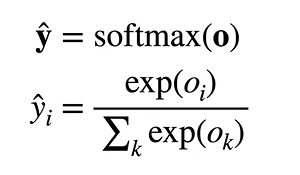

**softmax 和交叉熵损失**   
损失：交叉熵衡量预测值和真实值的区别    
梯度：softmax求得的预测值 - 真实值
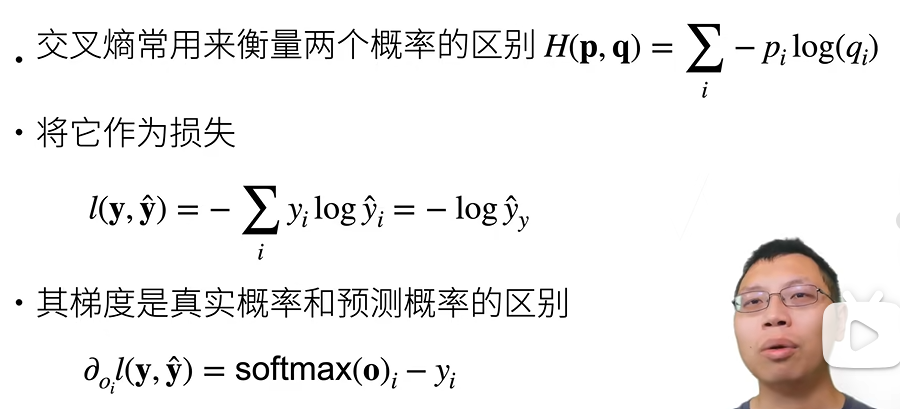

## 损失函数

L2 Loss ：均方损失 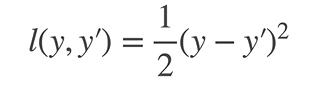
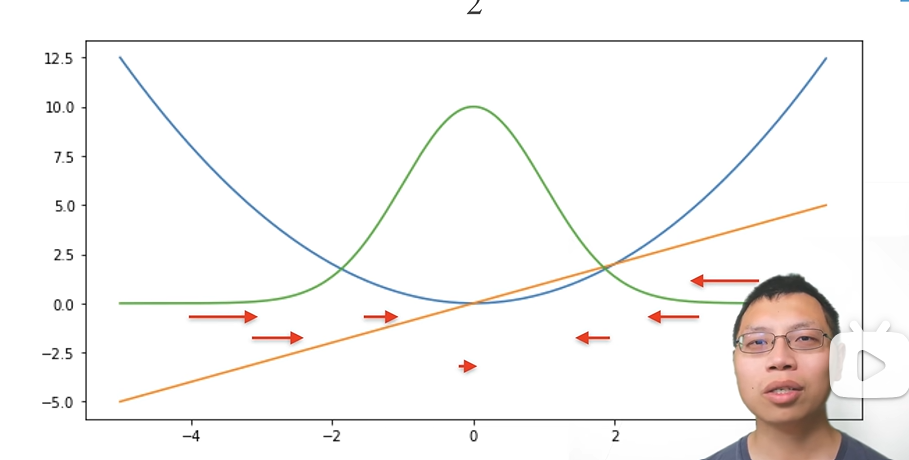
绿色是似然函数，橙色是梯度（假设真实值为0）

1. 概率（Probability）：参数 θ 已知，预测未来结果 x 出现的概率，即 P(x∣θ)。
2. 似然（Likelihood）：结果 x 已经发生了（已知数据），反推参数 θ 取何值时最合理，即 L(θ∣x)。
- 如果把所有的所有输出的取值集合看作一个事件，那么将每个输出取到对应值的概率相乘就是就是这个事件发生的概率，因为“任何已经发生的事件都有其最大概率”，所以需要极大化这个事件概率，这个事件发生的概率就是似然函数
- 然后如何极大化似然函数，求导，令导数等于0，然后解出未知参数，这样解出的未知参数就叫做参数的似然估计值。
- 然后根据softmax的定义，它就是每个输出取到某个值的一种映射概率，所以似然函数就是将所有输出的softmax相乘，然后极大化似然函数等价于极小化似然函数的负对数，那么将似然函数取负对数，根据对数函数的性质，连乘变成连加，这样得到的函数就是交叉熵

L1 Loss：  
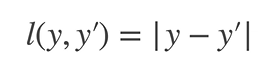
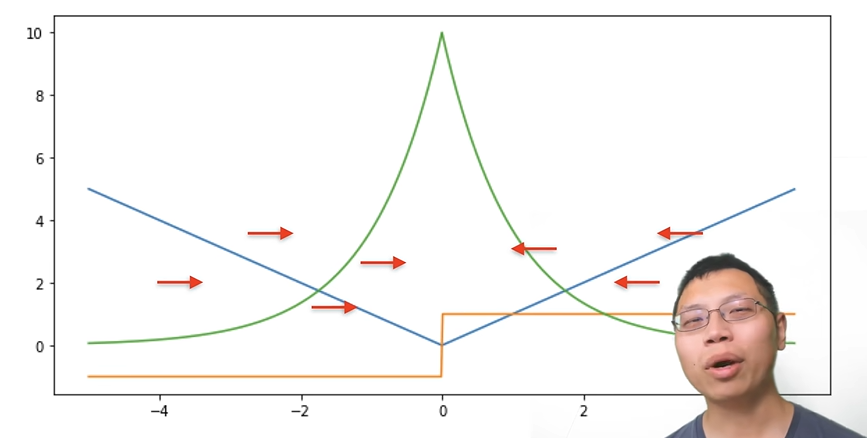

Huber's Robust Loss:
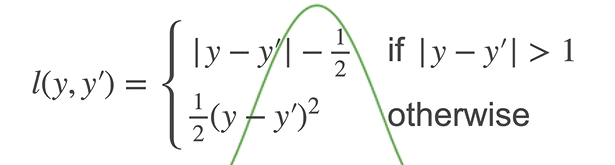
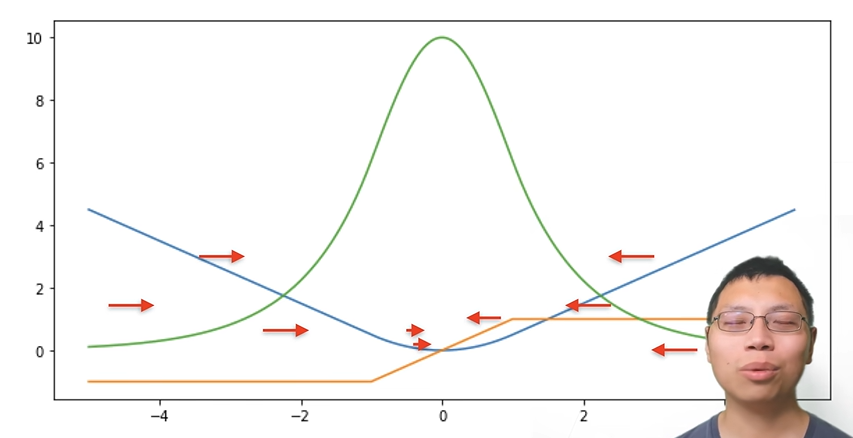

## softmax 从零开始

### 初始化参数

In [83]:
import torch
from IPython import display
from d2l import torch as d2l

读取数据集

In [84]:
## 读取小批量数据
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [85]:
num_inputs = 784
num_outputs = 10
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

### 定义softmax操作

In [86]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

实现softmax由三个步骤组成：
1. 对每个项求幂（使用exp）；
2. 对每一行求和（小批量中每个样本是一行），得到每个样本的规范化常数；
3. 将每一行除以其规范化常数，确保结果的和为1。

In [87]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition         # 这里应用了广播机制

In [88]:
#验证softmax函数
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1331, 0.1705, 0.4456, 0.0877, 0.1631],
         [0.9489, 0.0031, 0.0137, 0.0264, 0.0078]]),
 tensor([1., 1.]))

### 定义模型

In [89]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

### 损失函数

In [90]:
#2个样本在3个标签的预测概率
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]   
#y是标签索引，y_hat是预测概率，y_hat[[0, 1], y]表示取出第0行第0列和第1行第2列的元素，即0.1和0.5

tensor([0.1000, 0.5000])

In [91]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])
# y_hat[range(len(y_hat)), y]表示取出每个样本对应的预测概率，即第i个样本的预测概率为y_hat[i, y[i]]，
# 然后对这些预测概率取对数并取负号，得到交叉熵损失。
cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

### 分类精度

In [92]:
def accuracy(y_hat, y): #@save
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

In [93]:
accuracy(y_hat, y) / len(y)

0.5

In [94]:
def evaluate_accuracy(net, data_iter): #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval() # 将模型设置为评估模式
    metric = Accumulator(2) # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [95]:
class Accumulator: #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [96]:
evaluate_accuracy(net, test_iter)

0.0099

### 训练

In [97]:
def train_epoch_ch3(net, train_iter, loss, updater): #@save
    """训练模型⼀个迭代周期"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
    # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
        # 使⽤PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
        # 使⽤定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

In [98]:
class Animator: #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None, ylim=None, xscale='linear', yscale='linear',
        fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
        figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使⽤lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

训练函数

In [99]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater): #@save
    """训练模型"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [100]:
lr = 0.1
def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

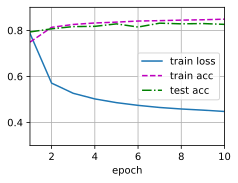

In [79]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

### 预测

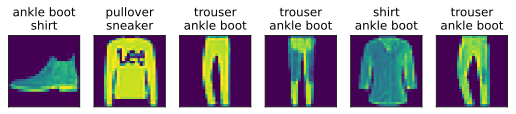

In [101]:
def predict_ch3(net, test_iter, n=6): #@save
    """预测标签"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
    
predict_ch3(net, test_iter)

## softmax简洁实现

In [103]:
import torch
from torch import nn
from d2l import torch as d2l
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [104]:
# PyTorch不会隐式地调整输⼊的形状。因此，
# 我们在线性层前定义了展平层（flatten），来调整⽹络输⼊的形状
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [105]:
#在交叉熵损失函数中传递未规范化的预测，并同时计算softmax及其对数
loss = nn.CrossEntropyLoss(reduction='none')

In [106]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

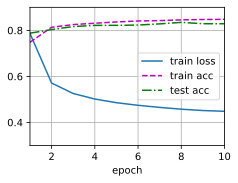

In [108]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)